In [2]:
import numpy as np
import pandas as pd

import statsmodels
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns; sns.set(style="whitegrid")

# Prices Round 0 Day 1
prices_1_df = pd.read_csv('prices_round_1_day_-1.csv', sep=';')
prices_2_df = pd.read_csv('prices_round_1_day_-2.csv', sep=";")
prices_0_df = pd.read_csv('prices_round_1_day_0.csv', sep=";")

prices_df = pd.concat([prices_2_df, prices_1_df, prices_0_df], ignore_index=True)
prices_df['day'] = prices_df['day'].map({-2: 1, -1: 2, 0: 3})  
prices_df['global_timestamp'] = (prices_df['day'] - 1) * 1000000 + prices_df['timestamp']
prices_df


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_timestamp
0,1,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0,0
1,1,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0,0
2,1,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0,100
3,1,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0,100
4,1,200,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,20.0,NaN,NaN,NaN,NaN,10001.5,0.0,200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,3,999700,INTARIAN_PEPPER_ROOT,12989.0,20.0,NaN,NaN,NaN,NaN,13007.0,10.0,13010.0,20.0,NaN,NaN,12998.0,0.0,2999700
59996,3,999800,INTARIAN_PEPPER_ROOT,NaN,NaN,NaN,NaN,NaN,NaN,13007.0,10.0,13010.0,24.0,NaN,NaN,13007.0,0.0,2999800
59997,3,999800,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10018.0,27.0,NaN,NaN,NaN,NaN,10018.0,0.0,2999800
59998,3,999900,ASH_COATED_OSMIUM,9998.0,21.0,NaN,NaN,NaN,NaN,10016.0,12.0,10019.0,21.0,NaN,NaN,10007.0,0.0,2999900


In [3]:
IPR_prices_df = prices_df.loc[prices_df['product'] == "INTARIAN_PEPPER_ROOT"].sort_values('global_timestamp')
IPR_prices_df['mid_price'] = IPR_prices_df['mid_price'].replace(0, np.nan).ffill()
IPR_prices_df.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_timestamp
0,1,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0,0
2,1,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0,100
4,1,200,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,20.0,NaN,NaN,NaN,NaN,10001.5,0.0,200
7,1,300,INTARIAN_PEPPER_ROOT,NaN,NaN,NaN,NaN,NaN,NaN,10006.0,10.0,10008.0,21.0,NaN,NaN,10006.0,0.0,300
9,1,400,INTARIAN_PEPPER_ROOT,9992.0,20.0,NaN,NaN,NaN,NaN,10006.0,12.0,10008.0,20.0,NaN,NaN,9999.0,0.0,400


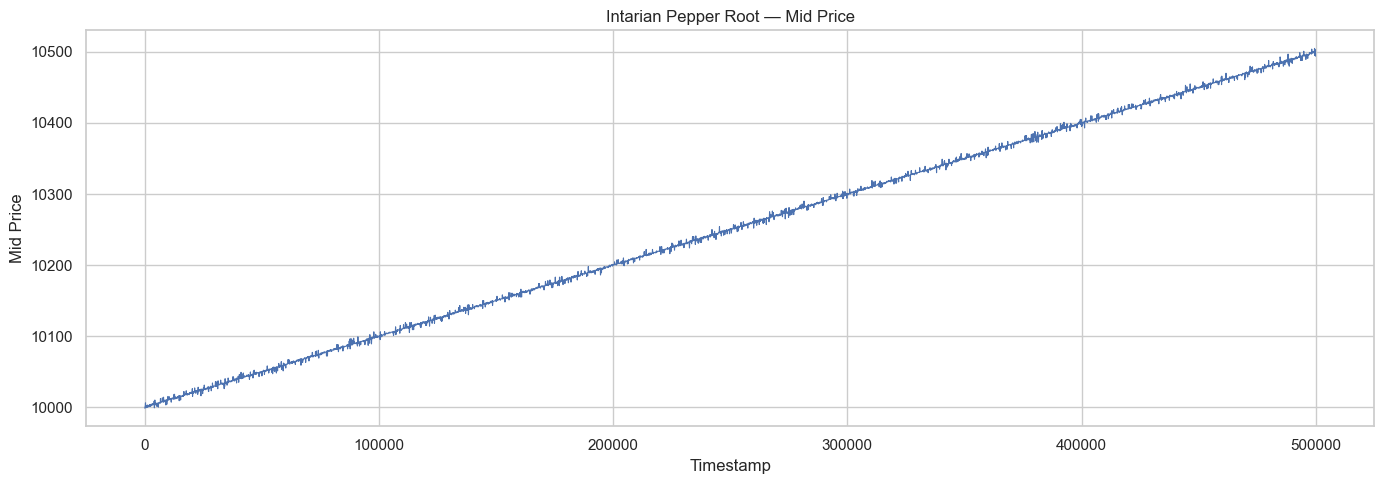

In [7]:
# Plot mid price
fig, ax = plt.subplots(figsize=(14, 5))
mask = (IPR_prices_df['global_timestamp'] >= 0) & (IPR_prices_df['global_timestamp'] < 500000)
ax.plot(IPR_prices_df.loc[mask, 'global_timestamp'], IPR_prices_df.loc[mask, 'mid_price'], linewidth=0.8)
ax.set_title('Intarian Pepper Root — Mid Price')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Mid Price')

plt.tight_layout()
plt.show()

In [ ]:
ACO_prices_df = prices_df.loc[prices_df['product'] == "ASH_COATED_OSMIUM"]
ACO_prices_df['mid_price'] = ACO_prices_df['mid_price'].replace(0, np.nan).ffill()
ACO_prices_df.head()

C:\Users\ktran\AppData\Local\Temp\ipykernel_27148\782679102.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ACO_prices_df['mid_price'] = ACO_prices_df['mid_price'].replace(0, np.nan).ffill()


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_timestamp
1,1,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0,0
3,1,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0,100
5,1,200,ASH_COATED_OSMIUM,9992.0,15.0,9989.0,30.0,NaN,NaN,10008.0,15.0,10010.0,30.0,NaN,NaN,10000.0,0.0,200
6,1,300,ASH_COATED_OSMIUM,9992.0,13.0,9989.0,26.0,NaN,NaN,10008.0,13.0,10010.0,26.0,NaN,NaN,10000.0,0.0,300
8,1,400,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10010.0,20.0,NaN,NaN,10000.0,0.0,400


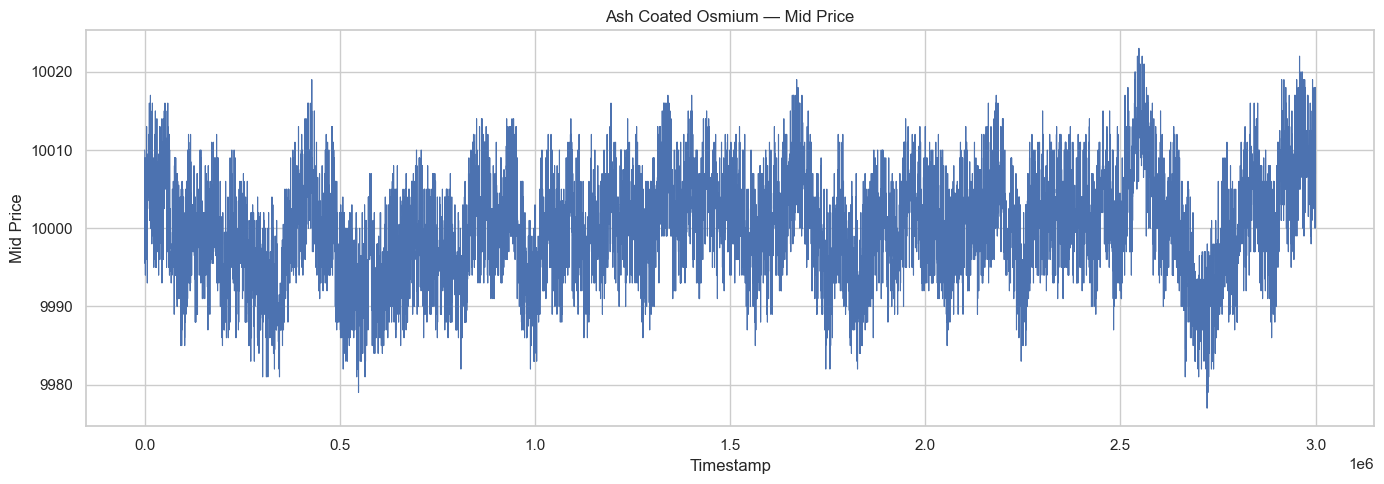

In [ ]:
# Plot mid price
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ACO_prices_df['global_timestamp'], ACO_prices_df['mid_price'], linewidth=0.8)
ax.set_title('Ash Coated Osmium — Mid Price')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Mid Price')

plt.tight_layout()
plt.show()

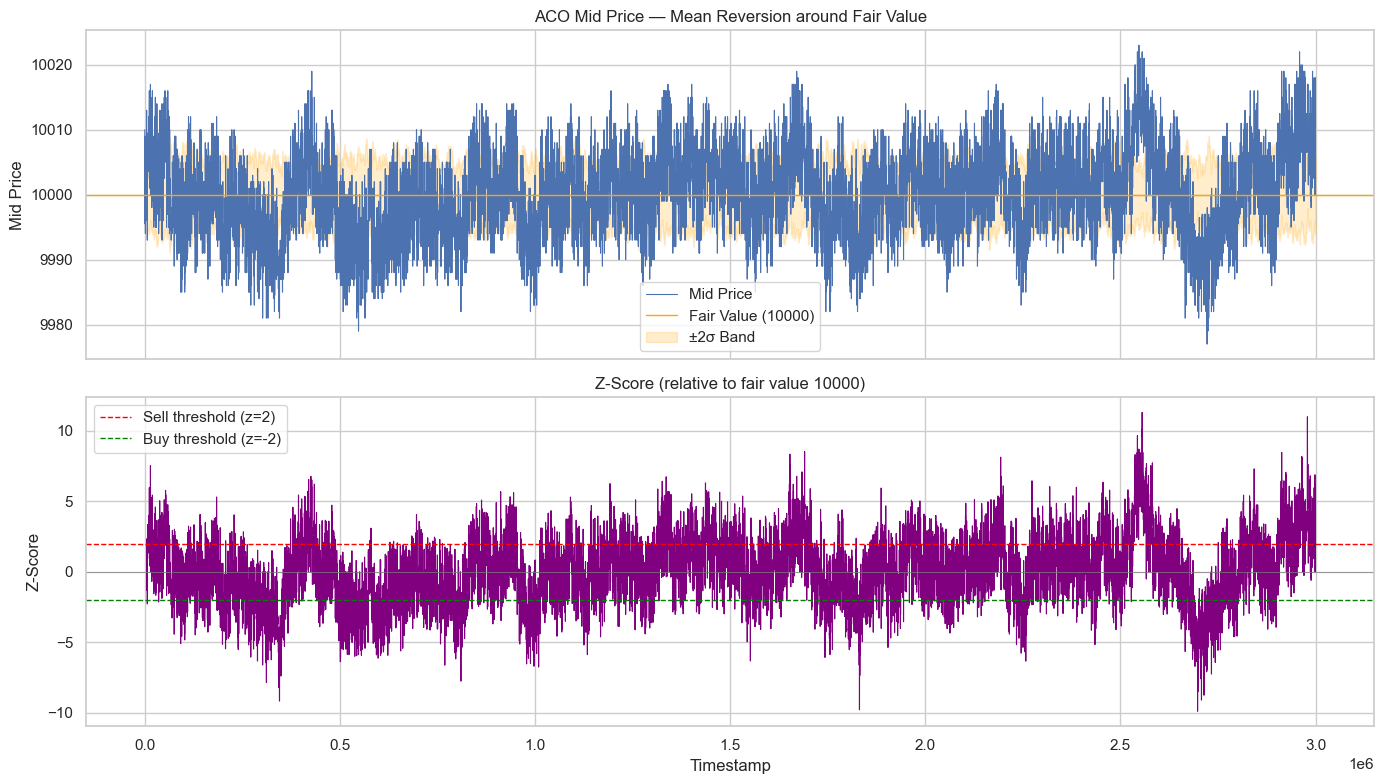

Fair Value: 10000
Rolling Std Window: 50
Z > 2 count: 4748
Z < -2 count: 4416


In [14]:
# Mean reversion setup — fixed mean at 10000
FAIR_VALUE = 10000
window = 50  # lookback window for std estimate

ACO_mr = ACO_prices_df.copy()
ACO_mr['rolling_std'] = ACO_mr['mid_price'].rolling(window).std()
ACO_mr['z_score'] = (ACO_mr['mid_price'] - FAIR_VALUE) / ACO_mr['rolling_std']

# Plot 1: Price with bands around fair value
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(ACO_mr['global_timestamp'], ACO_mr['mid_price'], linewidth=0.8, label='Mid Price')
axes[0].axhline(FAIR_VALUE, color='orange', linewidth=1, label=f'Fair Value ({FAIR_VALUE})')
axes[0].fill_between(ACO_mr['global_timestamp'],
                     FAIR_VALUE - 2 * ACO_mr['rolling_std'],
                     FAIR_VALUE + 2 * ACO_mr['rolling_std'],
                     alpha=0.2, color='orange', label='±2σ Band')
axes[0].set_title('ACO Mid Price — Mean Reversion around Fair Value')
axes[0].set_ylabel('Mid Price')
axes[0].legend()

# Plot 2: Z-score with trade thresholds
axes[1].plot(ACO_mr['global_timestamp'], ACO_mr['z_score'], linewidth=0.8, color='purple')
axes[1].axhline(2, color='red', linestyle='--', linewidth=1, label='Sell threshold (z=2)')
axes[1].axhline(-2, color='green', linestyle='--', linewidth=1, label='Buy threshold (z=-2)')
axes[1].axhline(0, color='gray', linestyle='-', linewidth=0.5)
axes[1].set_title('Z-Score (relative to fair value 10000)')
axes[1].set_xlabel('Timestamp')
axes[1].set_ylabel('Z-Score')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Fair Value: {FAIR_VALUE}")
print(f"Rolling Std Window: {window}")
print(f"Z > 2 count: {(ACO_mr['z_score'] > 2).sum()}")
print(f"Z < -2 count: {(ACO_mr['z_score'] < -2).sum()}")

In [ ]:
mean = ACO_prices_df['mid_price'].mean()
median = ACO_prices_df['mid_price'].median()
std = ACO_prices_df['mid_price'].std()

fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(ACO_prices_df['mid_price'], bins=50, edgecolor='black', alpha=0.7)
ax.axvline(mean, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean:.2f}')
ax.axvline(median, color='orange', linestyle='-', linewidth=1.5, label=f'Median: {median:.2f}')
ax.axvline(mean + std, color='green', linestyle=':', linewidth=1.2, label=f'±1 Std: {std:.2f}')
ax.axvline(mean - std, color='green', linestyle=':', linewidth=1.2)
ax.set_title('Ash Coated Osmium — Mid Price Distribution')
ax.set_xlabel('Mid Price')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

## ACO Statistical Analysis
Testing whether ASH_COATED_OSMIUM mid price has hidden patterns

In [19]:
# 1. Augmented Dickey-Fuller test — is the series mean-reverting?
adf_result = adfuller(ACO_prices_df['mid_price'].dropna())
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:", adf_result[4])
if adf_result[1] < 0.05:
    print("=> Stationary (mean-reverting) — reject unit root")
else:
    print("=> Non-stationary (has unit root) — cannot reject random walk")

ADF Statistic: -5.821452030895888
p-value: 4.1736589945832634e-07
Critical Values: {'1%': -3.4305682062715013, '5%': -2.8616364412703774, '10%': -2.566821332745785}
=> Stationary (mean-reverting) — reject unit root


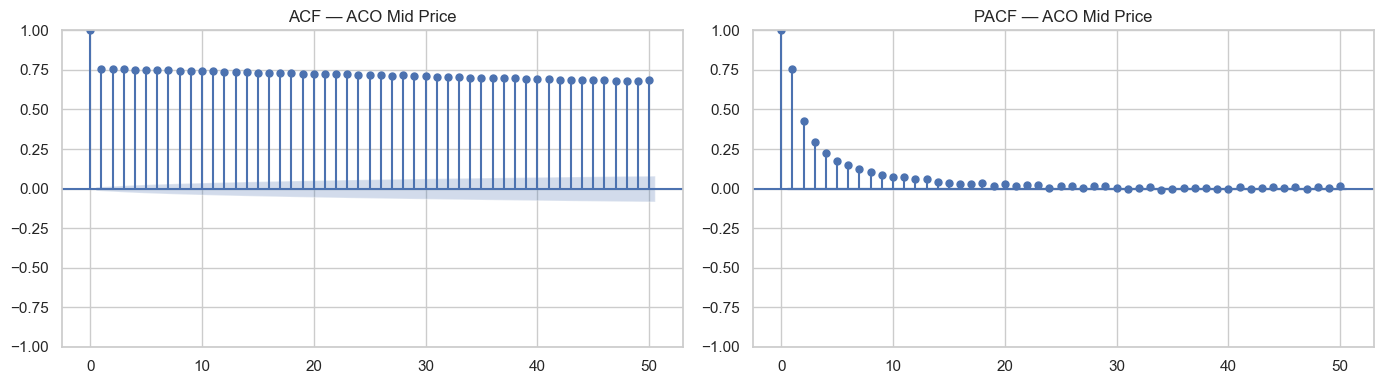

In [20]:
# 2. ACF / PACF — what lag structure exists?
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ACO_prices_df['mid_price'].dropna(), lags=50, ax=axes[0], title='ACF — ACO Mid Price')
plot_pacf(ACO_prices_df['mid_price'].dropna(), lags=50, ax=axes[1], title='PACF — ACO Mid Price')
plt.tight_layout()
plt.show()

In [21]:
# 3. Hurst exponent — mean-reverting (H<0.5), random walk (H≈0.5), or trending (H>0.5)?
def hurst_exponent(ts):
    ts = np.array(ts)
    lags = range(2, min(100, len(ts) // 2))
    tau = [np.std(np.subtract(ts[lag:], ts[:-lag])) for lag in lags]
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    return poly[0]

H = hurst_exponent(ACO_prices_df['mid_price'].dropna().values)
print(f"Hurst Exponent: {H:.4f}")
if H < 0.45:
    print("=> Mean-reverting")
elif H > 0.55:
    print("=> Trending")
else:
    print("=> Close to random walk")

Hurst Exponent: 0.0729
=> Mean-reverting


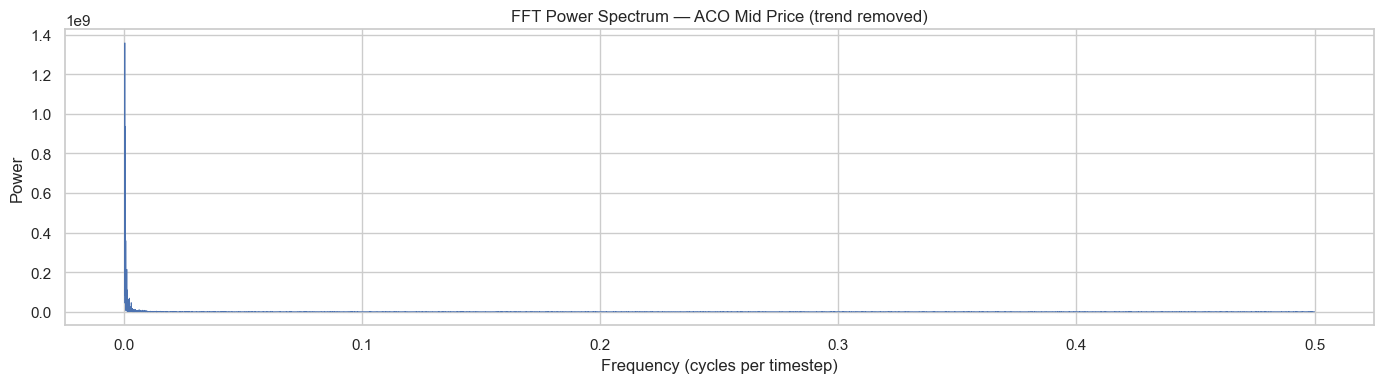

Top 5 dominant periods (in timesteps):
  Frequency: 0.000233, Period: 4286 timesteps, Power: 1358268391
  Frequency: 0.000467, Period: 2143 timesteps, Power: 936716372
  Frequency: 0.000200, Period: 5000 timesteps, Power: 848171895
  Frequency: 0.000133, Period: 7500 timesteps, Power: 433032649
  Frequency: 0.000400, Period: 2500 timesteps, Power: 428007861


In [18]:
# 4. FFT — detect hidden periodic cycles
mid = ACO_prices_df['mid_price'].dropna().values
mid_detrended = mid - np.mean(mid)

fft_vals = np.fft.rfft(mid_detrended)
fft_power = np.abs(fft_vals) ** 2
freqs = np.fft.rfftfreq(len(mid_detrended))

# Skip very low frequencies (trend) — only look at periods shorter than 1/3 of the series
min_freq = 3 / len(mid_detrended)
mask = freqs > min_freq

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(freqs[mask], fft_power[mask], linewidth=0.6)
ax.set_title('FFT Power Spectrum — ACO Mid Price (trend removed)')
ax.set_xlabel('Frequency (cycles per timestep)')
ax.set_ylabel('Power')
plt.tight_layout()
plt.show()

# Top 5 dominant frequencies (excluding trend)
masked_power = fft_power.copy()
masked_power[~mask] = 0
top_idx = np.argsort(masked_power)[-5:][::-1]
print("Top 5 dominant periods (in timesteps):")
for idx in top_idx:
    period = 1 / freqs[idx] if freqs[idx] > 0 else np.inf
    print(f"  Frequency: {freqs[idx]:.6f}, Period: {period:.0f} timesteps, Power: {fft_power[idx]:.0f}")

In [ ]:
# 5. Returns distribution — normality check
returns = ACO_prices_df['mid_price'].dropna().pct_change().dropna()

from scipy.stats import jarque_bera, skew, kurtosis

jb_stat, jb_p = jarque_bera(returns)
print(f"Skewness: {skew(returns):.4f}")
print(f"Kurtosis: {kurtosis(returns):.4f}")
print(f"Jarque-Bera stat: {jb_stat:.2f}, p-value: {jb_p:.6f}")
if jb_p < 0.05:
    print("=> Returns are NOT normally distributed (fat tails / skew present)")
else:
    print("=> Returns appear normally distributed")

fig, ax = plt.subplots(figsize=(14, 4))
ax.hist(returns, bins=80, edgecolor='black', alpha=0.7, density=True)
ax.set_title('ACO Mid Price Returns Distribution')
ax.set_xlabel('Return')
ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

$i$ is the order depth:
$$ \text{VWAP}_t = \frac{\sum_i (ASK_i)_t \cdot (BID_i)\_VOL_t + \sum_i(BID_i)_t \cdot (ASK_i)\_VOL_t}{\sum_i ASK_i\_VOL_t + BID_i\_VOL_t} $$